In [31]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## Операции с массивом

In [18]:
np.random.seed(42)
arr = np.random.randint(0, 100, 10)
arr

array([51, 92, 14, 71, 60, 20, 82, 86, 74, 74])

In [19]:
print("max:", arr.max())
print("min:", arr.min())
print("mean:", arr.mean())

max: 92
min: 14
mean: 62.4


In [20]:
sorted(arr)

[np.int64(14),
 np.int64(20),
 np.int64(51),
 np.int64(60),
 np.int64(71),
 np.int64(74),
 np.int64(74),
 np.int64(82),
 np.int64(86),
 np.int64(92)]

In [21]:
arr.reshape(5, 2)

array([[51, 92],
       [14, 71],
       [60, 20],
       [82, 86],
       [74, 74]])

In [22]:
mat = np.arange(0, 25).reshape(5, 5)
mat

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19],
       [20, 21, 22, 23, 24]])

In [23]:
mat.T

array([[ 0,  5, 10, 15, 20],
       [ 1,  6, 11, 16, 21],
       [ 2,  7, 12, 17, 22],
       [ 3,  8, 13, 18, 23],
       [ 4,  9, 14, 19, 24]])

In [24]:
A = np.array([[1, 2],
              [3, 4]])

B = np.array([[5, 6],
              [7, 8]])

print("A:\n", A)
print("B:\n", B)

print("\nТранспонирование A:")
print(A.T)

print("\nМатричное умножение:")
print(A @ B)

print("\nПоэлементное умножение:")
print(A * B)

A:
 [[1 2]
 [3 4]]
B:
 [[5 6]
 [7 8]]

Транспонирование A:
[[1 3]
 [2 4]]

Матричное умножение:
[[19 22]
 [43 50]]

Поэлементное умножение:
[[ 5 12]
 [21 32]]


In [25]:
arr[arr > 50]

array([51, 92, 71, 60, 82, 86, 74, 74])

In [26]:
np.where(arr > 50, arr, 0)

array([51, 92,  0, 71, 60,  0, 82, 86, 74, 74])

## Выделение объекта на картинке

In [32]:
img = cv2.imread("art.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(gray, (7, 7), 0)
edges = cv2.Canny(blurred, 30, 100)

kernel = np.ones((5, 5))
edges = cv2.dilate(edges, kernel, iterations=2)
edges = cv2.erode(edges, kernel, iterations=1)

contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

min_area = 500
contours = [c for c in contours if cv2.contourArea(c) > min_area]

vis = img_rgb.copy()
for c in contours:
    x, y, w, h = cv2.boundingRect(c)
    cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 255, 0), 3)

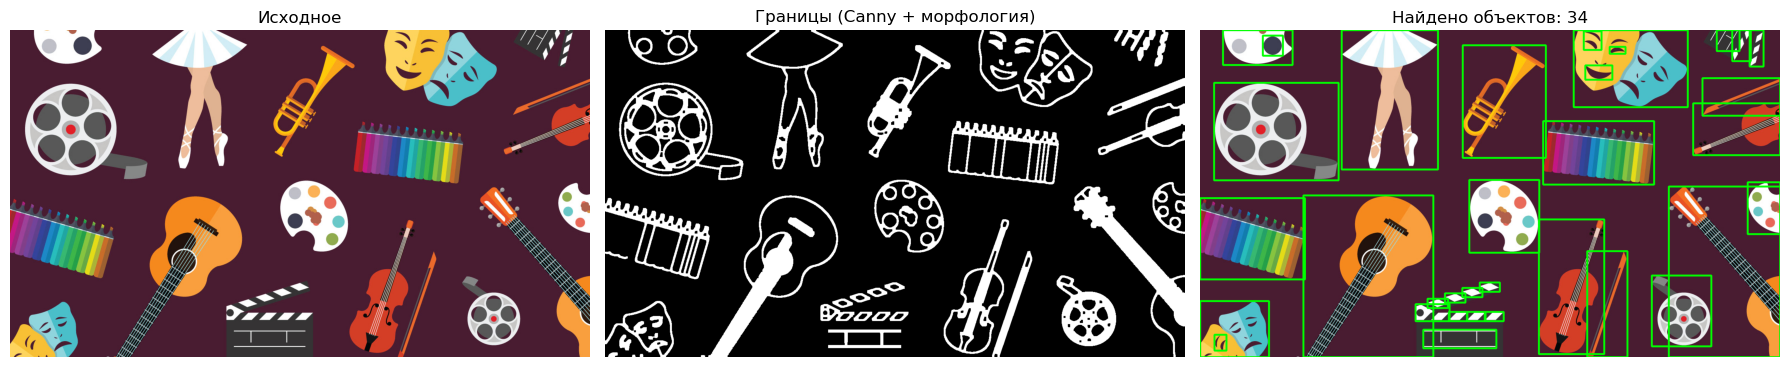

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_rgb)
axes[0].set_title("Исходное")
axes[0].axis("off")

axes[1].imshow(edges, cmap="gray")
axes[1].set_title("Границы (Canny + морфология)")
axes[1].axis("off")

axes[2].imshow(vis)
axes[2].set_title(f"Найдено объектов: {len(contours)}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Своя функция rectangle

In [34]:
def my_rectangle(img, pt1, pt2, color, thickness=2):
    result = img.copy()
    x1, y1 = pt1
    x2, y2 = pt2

    result[y1:y1+thickness, x1:x2+1] = color
    result[y2-thickness+1:y2+1, x1:x2+1] = color
    result[y1:y2+1, x1:x1+thickness] = color
    result[y1:y2+1, x2-thickness+1:x2+1] = color

    return result

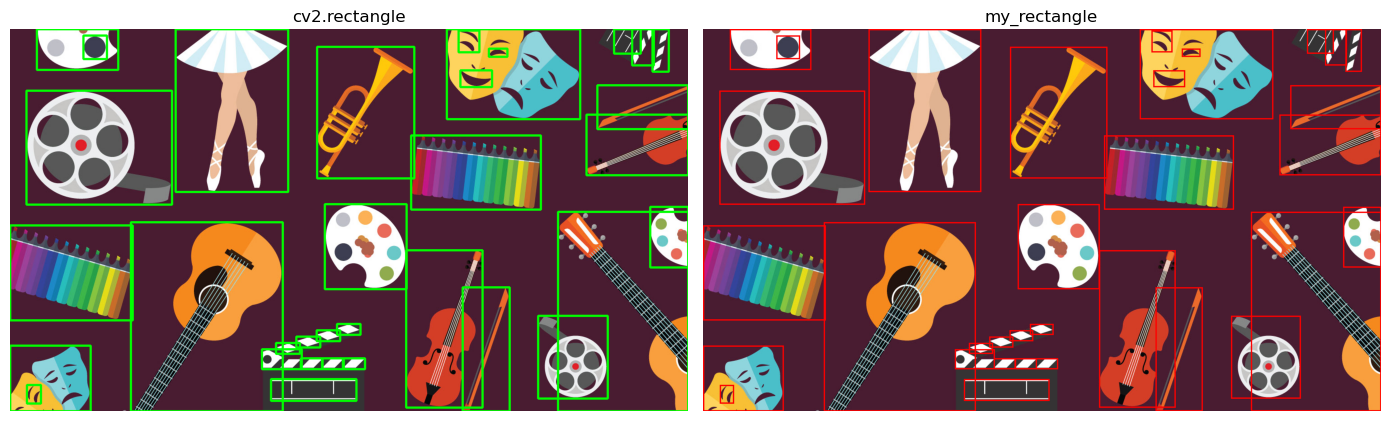

In [35]:
res = img_rgb.copy()
for c in contours:
    x, y, w, h = cv2.boundingRect(c)
    res = my_rectangle(res, (x, y), (x+w, y+h), (255, 0, 0), 3)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(vis)
axes[0].set_title("cv2.rectangle")
axes[0].axis("off")

axes[1].imshow(res)
axes[1].set_title("my_rectangle")
axes[1].axis("off")

plt.tight_layout()
plt.show()